In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random

params = {
   'axes.labelsize': 20,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 20,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [2]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [3]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)


def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

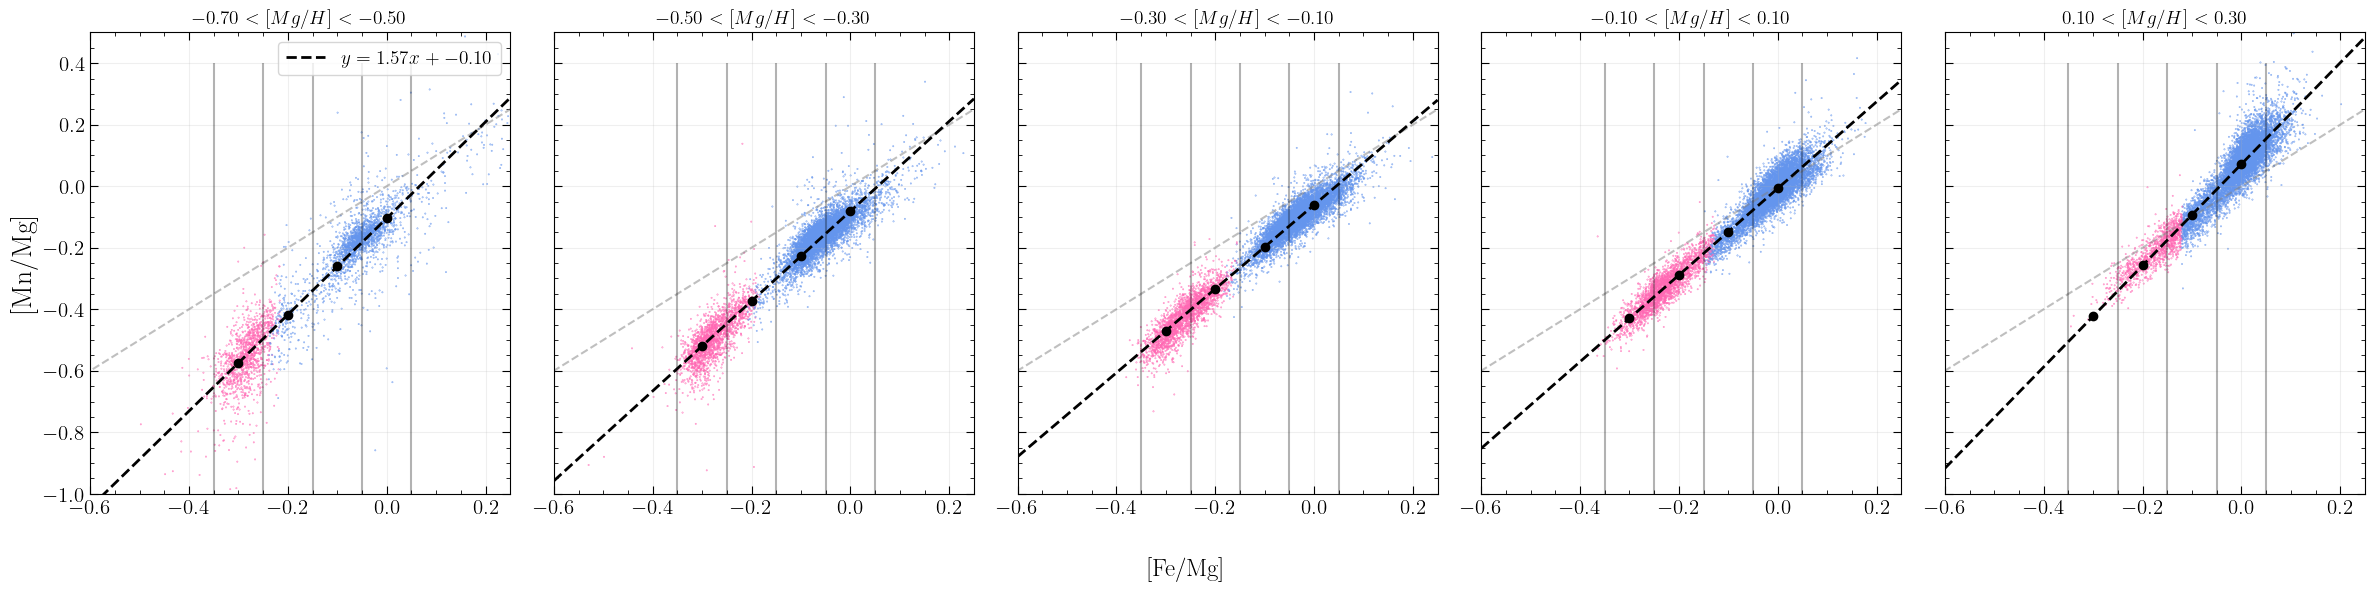

In [4]:
from scipy.stats import linregress

fig_x = 24
fig_y = 6

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = len(axes)  # or len(mg_h_big_bin_centers)

slopes_mn_mg = np.zeros(n_bins)
intercepts_mn_mg = np.zeros(n_bins)

for i, ax in enumerate(axes):
    # Select data in this bin
    subset = data[data['MG_H_big_bin'] == i]
    downsampled_data = downsample(subset, 10000)

    x = downsampled_data['FE_MG']
    y = downsampled_data['MN_MG']

    # Scatter
    ax.scatter(x, y, s=0.1, color=downsampled_data['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # ---- LINEAR FIT ----
    # Remove NaNs just in case
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) > 2:
        slope, intercept, r_value, _, _ = linregress(x_fit, y_fit)
        slopes_mn_mg[i] = slope
        intercepts_mn_mg[i] = intercept

        # Plot fit
        xs_fit = np.linspace(-0.60, 0.25, 100)
        ys_fit = slope * xs_fit + intercept
        ax.plot(xs_fit, ys_fit, color='black', lw=2,
                label=rf'$y={slope:.2f}x+{intercept:.2f}$', linestyle='--')
        
        # Evaluate fit at bin centers
        y_centers = slope * fe_mg_bin_centers + intercept

        # Plot as points (recommended)
        ax.plot(fe_mg_bin_centers, y_centers, 'o', color='black', ms=6)
        ax.vlines(fe_mg_bin_edges,  ymin=-1.5, ymax=0.40, color='black', alpha=0.3)

        # Optional: connect them
        #ax.plot(fe_mg_bin_centers, y_centers, linestyle='--', color='black', alpha=0.7)

    if i == 0:
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylabel("[Mn/Mg]")

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.00, 0.50)


fig.supxlabel('[Fe/Mg]')
plt.tight_layout()

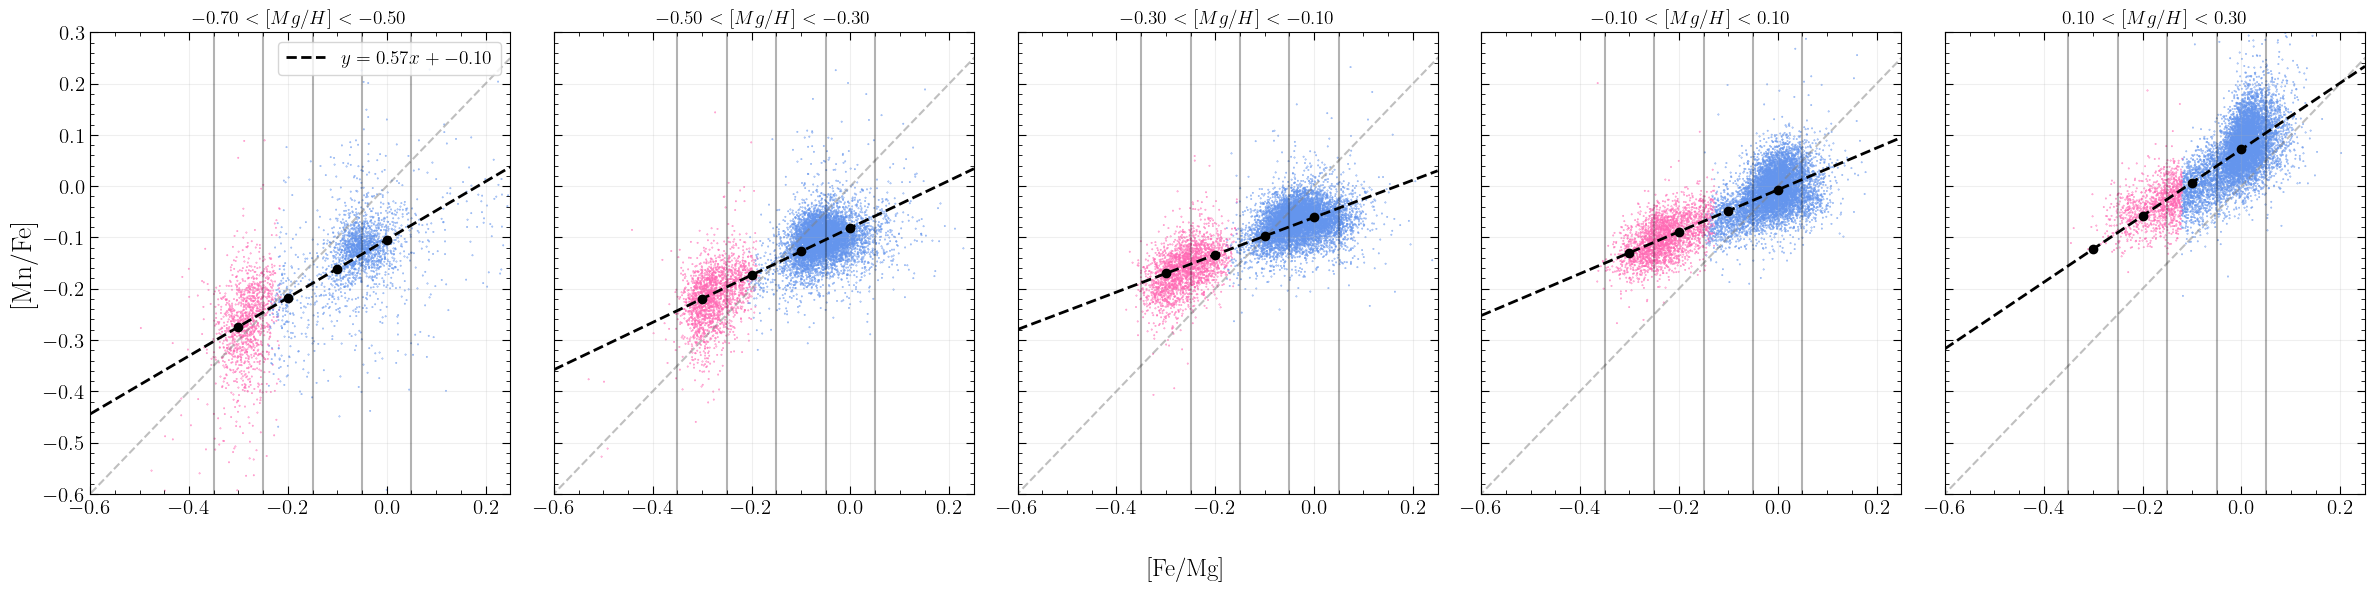

In [5]:
from scipy.stats import linregress

fig_x = 24
fig_y = 6

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = len(axes)  # or len(mg_h_big_bin_centers)

slopes_mn_fe = np.zeros(n_bins)
intercepts_mn_fe = np.zeros(n_bins)

for i, ax in enumerate(axes):
    # Select data in this bin
    subset = data[data['MG_H_big_bin'] == i]
    downsampled_data = downsample(subset, 10000)

    x = downsampled_data['FE_MG']
    y = downsampled_data['MN_FE']

    # Scatter
    ax.scatter(x, y, s=0.1, color=downsampled_data['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # ---- LINEAR FIT ----
    # Remove NaNs just in case
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) > 2:
        slope, intercept, r_value, _, _ = linregress(x_fit, y_fit)
        slopes_mn_fe[i] = slope
        intercepts_mn_fe[i] = intercept

        # Plot fit
        xs_fit = np.linspace(-0.60, 0.25, 100)
        ys_fit = slope * xs_fit + intercept
        ax.plot(xs_fit, ys_fit, color='black', lw=2,
                label=rf'$y={slope:.2f}x+{intercept:.2f}$', linestyle='--')
        
        # Evaluate fit at bin centers
        y_centers = slope * fe_mg_bin_centers + intercept

        # Plot as points (recommended)
        ax.plot(fe_mg_bin_centers, y_centers, 'o', color='black', ms=6)
        ax.vlines(fe_mg_bin_edges,  ymin=-1.5, ymax=0.40, color='black', alpha=0.3)

        # Optional: connect them
        #ax.plot(fe_mg_bin_centers, y_centers, linestyle='--', color='black', alpha=0.7)

    if i == 0:
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylabel("[Mn/Fe]")

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.60, 0.30)


fig.supxlabel('[Fe/Mg]')
plt.tight_layout()

In [6]:
gcc_Mn_def = 0.40
gcc_ratio_def = 2
alpha_cc_def = 0.60
alpha_ia_def = 0.30

'''
gcc_Mn_def = 0.30
gcc_ratio_def = 2
alpha_cc_def = 0.30
alpha_ia_def = 0.30
'''

'\ngcc_Mn_def = 0.30\ngcc_ratio_def = 2\nalpha_cc_def = 0.30\nalpha_ia_def = 0.30\n'

In [7]:
# SFRs

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1, m_g_array_rise_fall_2, m_g_array_rise_fall_3]

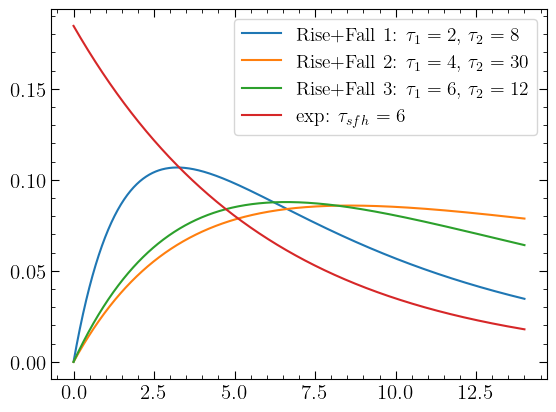

In [8]:
plt.plot(t_array, m_g_array_rise_fall_1, label = r'Rise+Fall 1: $\tau_1 = 2$, $\tau_2 = 8$')
plt.plot(t_array, m_g_array_rise_fall_2, label = r'Rise+Fall 2: $\tau_1 = 4$, $\tau_2 = 30$')
plt.plot(t_array, m_g_array_rise_fall_3, label = r'Rise+Fall 3: $\tau_1 = 6$, $\tau_2 = 12$')
#plt.plot(t_array, m_g_array_const, label = r'Const')
plt.plot(t_array, m_g_array_exp, label = r'exp: $\tau_{sfh} = 6$')

plt.legend()

In [9]:
etas = np.logspace(-2, 1, 10)
tau_stars = np.linspace(0.5, 6, 10)
print(etas)

[ 0.01        0.02154435  0.04641589  0.1         0.21544347  0.46415888
  1.          2.15443469  4.64158883 10.        ]


In [10]:
gals_list_all = []

n_gals = len(etas) * len(tau_stars) * len(sfrs)
print("n_gals = ", n_gals)

n_gals =  500


In [11]:
for i_eta in range(len(etas)):
    for i_taustar in range(len(tau_stars)):
        for i_sfrs in range(len(sfrs)):
            eta = etas[i_eta]
            tau_star = tau_stars[i_taustar]
            sfr = sfrs[i_sfrs]

            gals_list_all.append(evo.Galaxy(t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                                     eta=eta, Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_def, g_ratio_Mn=gcc_ratio_def,
                                     alpha_cc_Mn=alpha_cc_def, alpha_Ia_Mn=alpha_ia_def))

In [12]:
len(gals_list_all)

500

In [ ]:
random.seed(42)
random_gals_list = random.sample(gals_list_all, 10)

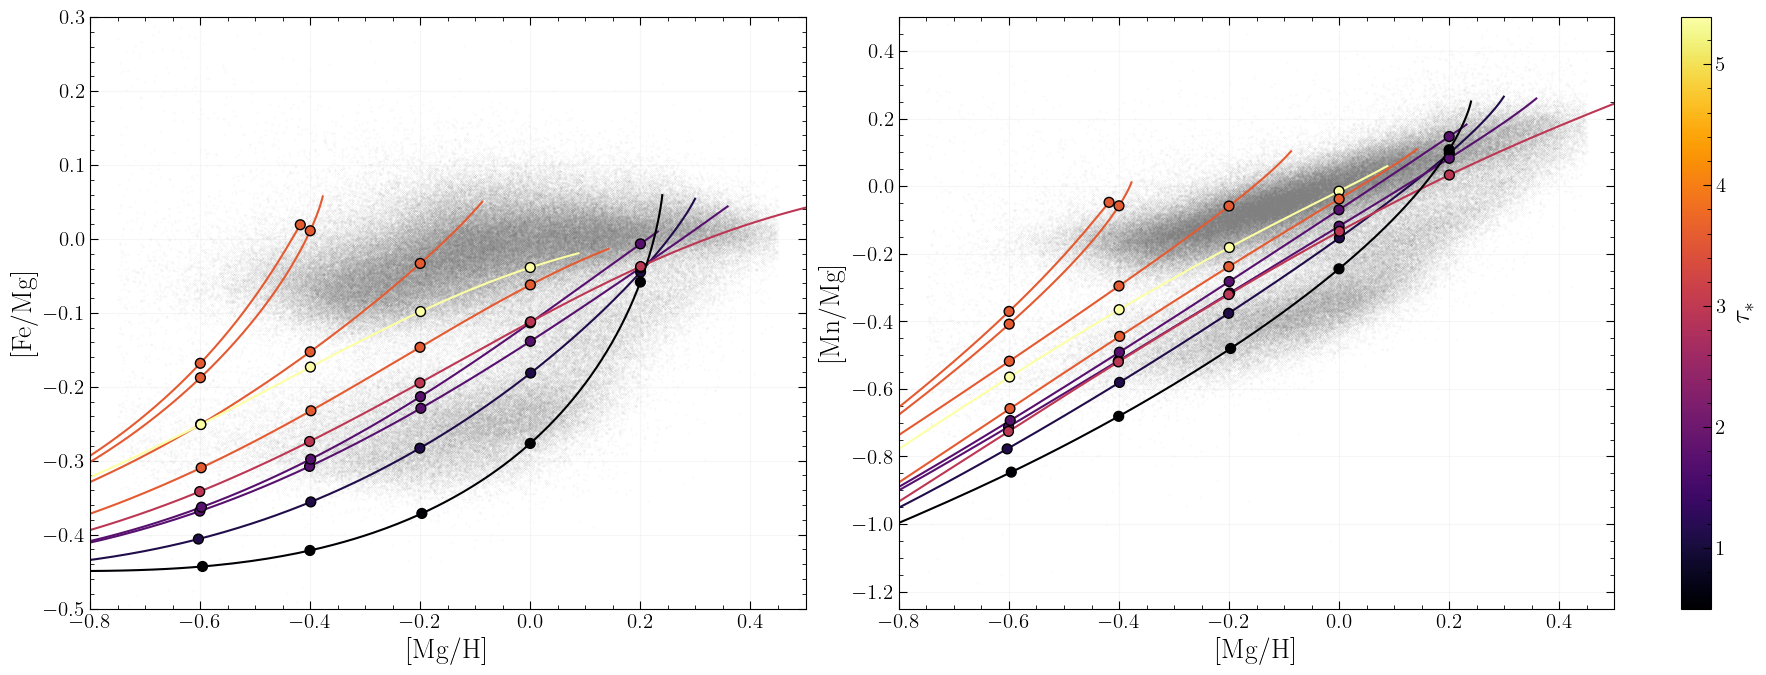

In [28]:
# --- NEW: Extract tau* values to normalize the colormap ---
tau_stars = [gal.tau_star_arr[0] for gal in random_gals_list]
vmin, vmax = min(tau_stars), max(tau_stars)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('inferno')

plt.figure(figsize=(18,7))
tol = np.diff(mg_h_big_bin_centers).mean() / 10 # adaptive tolerance

plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['FE_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    eta = gal.eta_arr[0]
    taustar = gal.tau_star_arr[0]
    sfr = gal.m_g_array
    if np.array_equal(sfr, m_g_array_const):
        sfr_label = "const SFR"
    elif np.array_equal(sfr, m_g_array_exp):
        sfr_label = "exp SFR"
    elif np.array_equal(sfr, m_g_array_rise_fall_1):
        sfr_label = "rise+fall  1"
    elif np.array_equal(sfr, m_g_array_rise_fall_2):
        sfr_label = "rise+fall  2"
    elif np.array_equal(sfr, m_g_array_rise_fall_3):
        sfr_label = "rise+fall  3"
    else:
        sfr_label = "unknown SFR"
        
    # --- NEW: Get color for this specific tau* ---
    current_color = cmap(norm(taustar))
        
    plt.plot(gal.Mg_H, gal.Fe_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to tau* ---
    plt.scatter(gal.Mg_H[idx_valid], gal.Fe_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                c=[taustar]*len(idx_valid), cmap=cmap, norm=norm,
                label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

#plt.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
plt.xlim(-0.8, 0.5)
plt.ylim(-0.5, 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid(True, alpha = 0.1)       


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['MN_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    taustar = gal.tau_star_arr[0]
    
    # --- NEW: Apply color mapping here too ---
    current_color = cmap(norm(taustar))
    
    plt.plot(gal.Mg_H, gal.Mn_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to tau* ---
    sc = plt.scatter(gal.Mg_H[idx_valid], gal.Mn_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                     c=[taustar]*len(idx_valid), cmap=cmap, norm=norm)

#plt.legend()
plt.xlim(-0.8, 0.5)
plt.ylim(-1.25, 0.5)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.grid(True, alpha = 0.1)

plt.tight_layout()

# --- NEW: Add a shared colorbar for both subplots ---
cbar = plt.colorbar(sc, ax=plt.gcf().axes, fraction=0.05, pad=0.04)
cbar.set_label(r'$\tau_*$', fontsize=20)
plt.show()

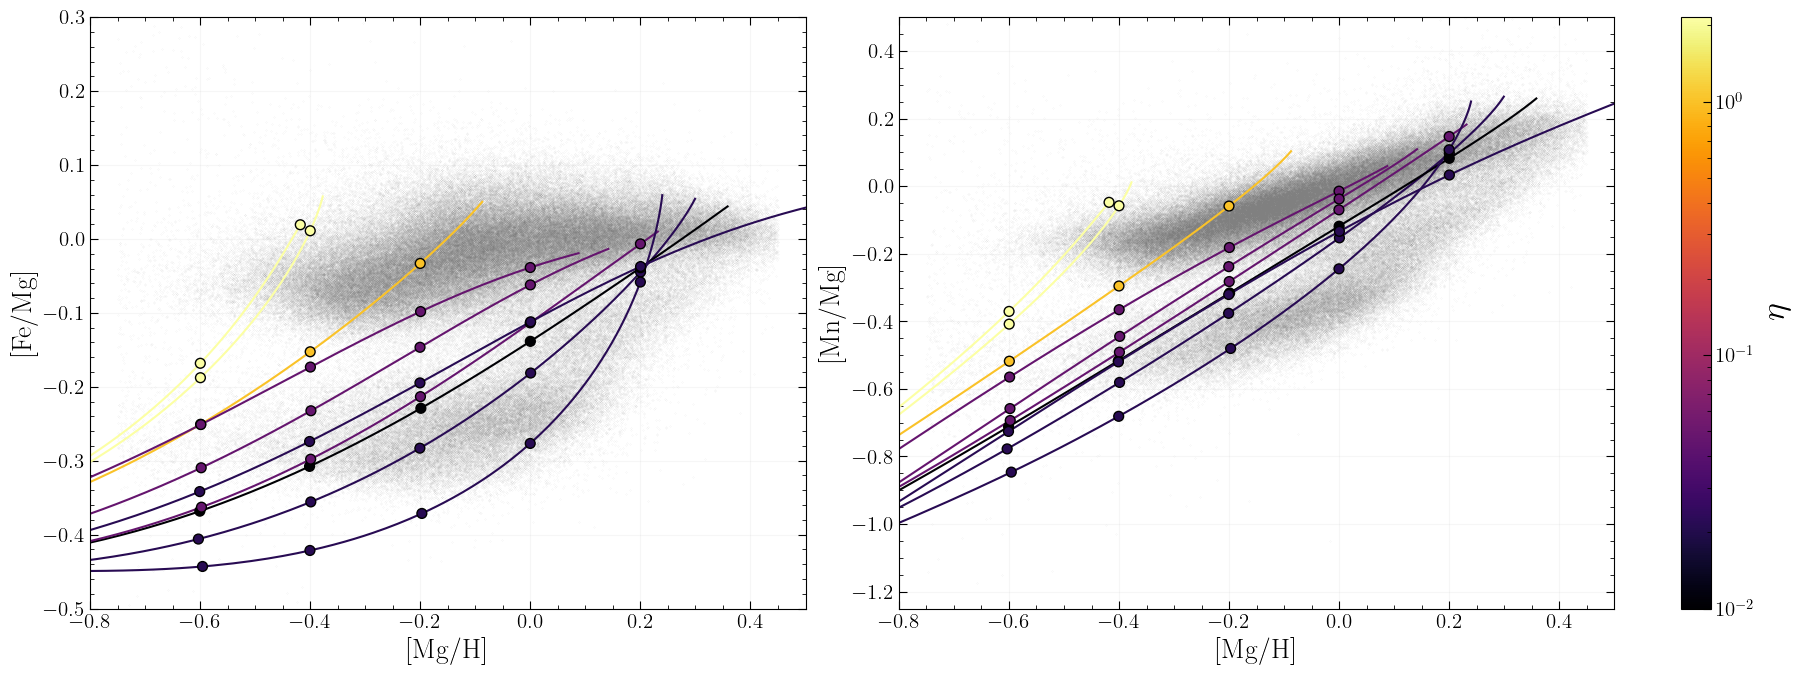

In [29]:
# --- NEW: Extract tau* values to normalize the colormap ---
etas_for_plotting = [gal.eta_arr[0] for gal in random_gals_list]
vmin, vmax = min(etas_for_plotting), max(etas_for_plotting)
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('inferno')

plt.figure(figsize=(18,7))
tol = np.diff(mg_h_big_bin_centers).mean() / 10 # adaptive tolerance

plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['FE_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    eta = gal.eta_arr[0]
    taustar = gal.tau_star_arr[0]
    sfr = gal.m_g_array
    if np.array_equal(sfr, m_g_array_const):
        sfr_label = "const SFR"
    elif np.array_equal(sfr, m_g_array_exp):
        sfr_label = "exp SFR"
    elif np.array_equal(sfr, m_g_array_rise_fall_1):
        sfr_label = "rise+fall  1"
    elif np.array_equal(sfr, m_g_array_rise_fall_2):
        sfr_label = "rise+fall  2"
    elif np.array_equal(sfr, m_g_array_rise_fall_3):
        sfr_label = "rise+fall  3"
    else:
        sfr_label = "unknown SFR"
        
    # --- NEW: Get color for this specific tau* ---
    current_color = cmap(norm(eta))
        
    plt.plot(gal.Mg_H, gal.Fe_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to eta ---
    plt.scatter(gal.Mg_H[idx_valid], gal.Fe_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                c=[eta]*len(idx_valid), cmap=cmap, norm=norm,
                label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

#plt.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
plt.xlim(-0.8, 0.5)
plt.ylim(-0.5, 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid(True, alpha = 0.1)       


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['MN_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    taustar = gal.tau_star_arr[0]
    eta = gal.eta_arr[0]
    
    # --- NEW: Apply color mapping here too ---
    current_color = cmap(norm(eta))
    
    plt.plot(gal.Mg_H, gal.Mn_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to eta ---
    sc = plt.scatter(gal.Mg_H[idx_valid], gal.Mn_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                     c=[eta]*len(idx_valid), cmap=cmap, norm=norm)

#plt.legend()
plt.xlim(-0.8, 0.5)
plt.ylim(-1.25, 0.5)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.grid(True, alpha = 0.1)

plt.tight_layout()

# --- NEW: Add a shared colorbar for both subplots ---
cbar = plt.colorbar(sc, ax=plt.gcf().axes, fraction=0.05, pad=0.04)
cbar.set_label(r'$\eta$', fontsize=25)
plt.show()

In [30]:
# --- USER'S DEFINITIONS ---
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []
    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            crossed = False
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    crossed = True
                    break
            if not crossed:
                endpoints.append(-1) # Critical fix to maintain 1:1 mapping with galaxies
        endpoints_gals.append(np.array(endpoints))
    return endpoints_gals

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

In [31]:
gals_list = random_gals_list

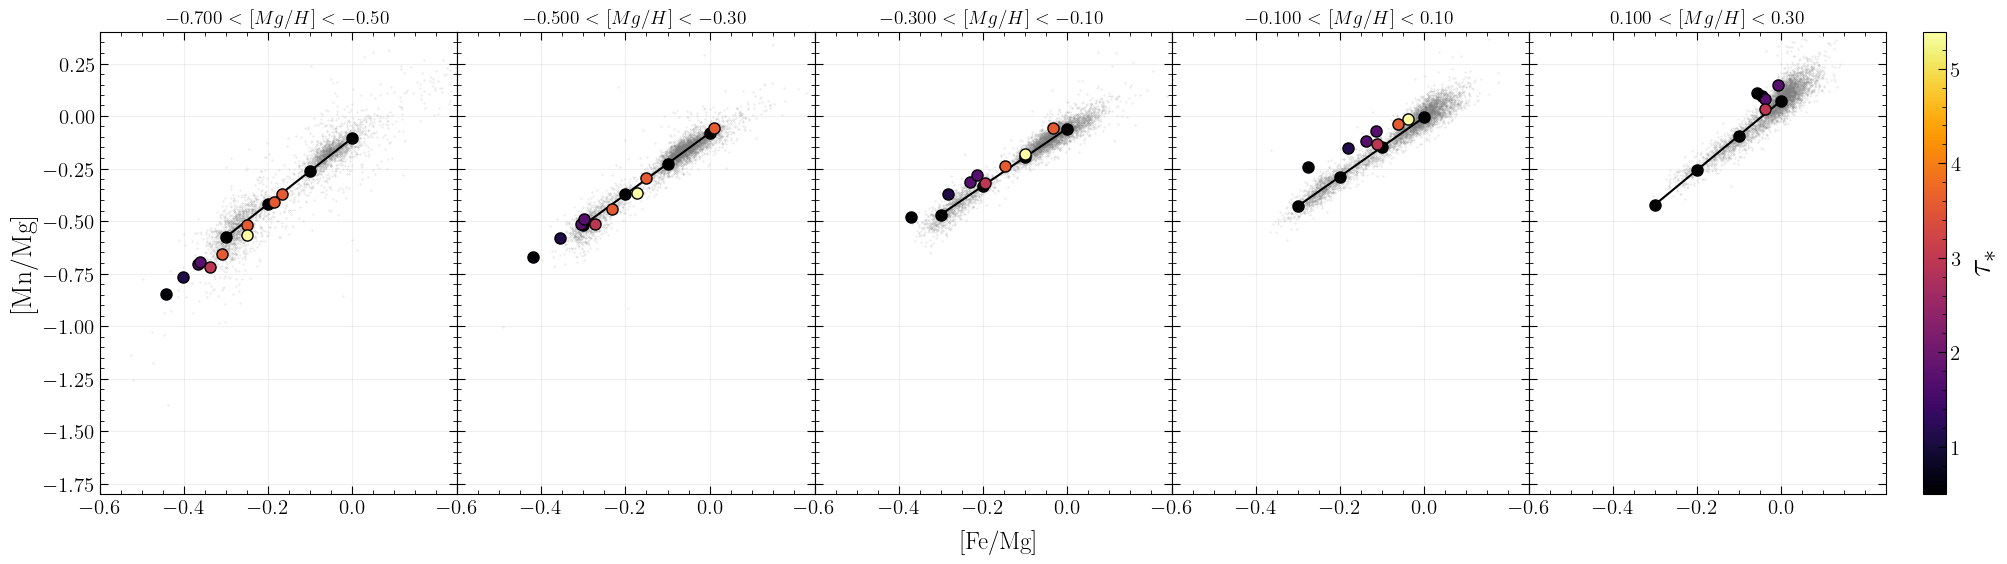

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6

# --- Extract tau* values for the colormap ---
tau_stars = [gal.tau_star_arr[0] for gal in gals_list]
norm = mcolors.Normalize(vmin=min(tau_stars), vmax=max(tau_stars))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_mg = gal.Mn_Mg[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(taustar))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_mg, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.8, 0.40) # Adjusted ylim for Mn/Mg

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\tau_*$', fontsize=25)

plt.show()

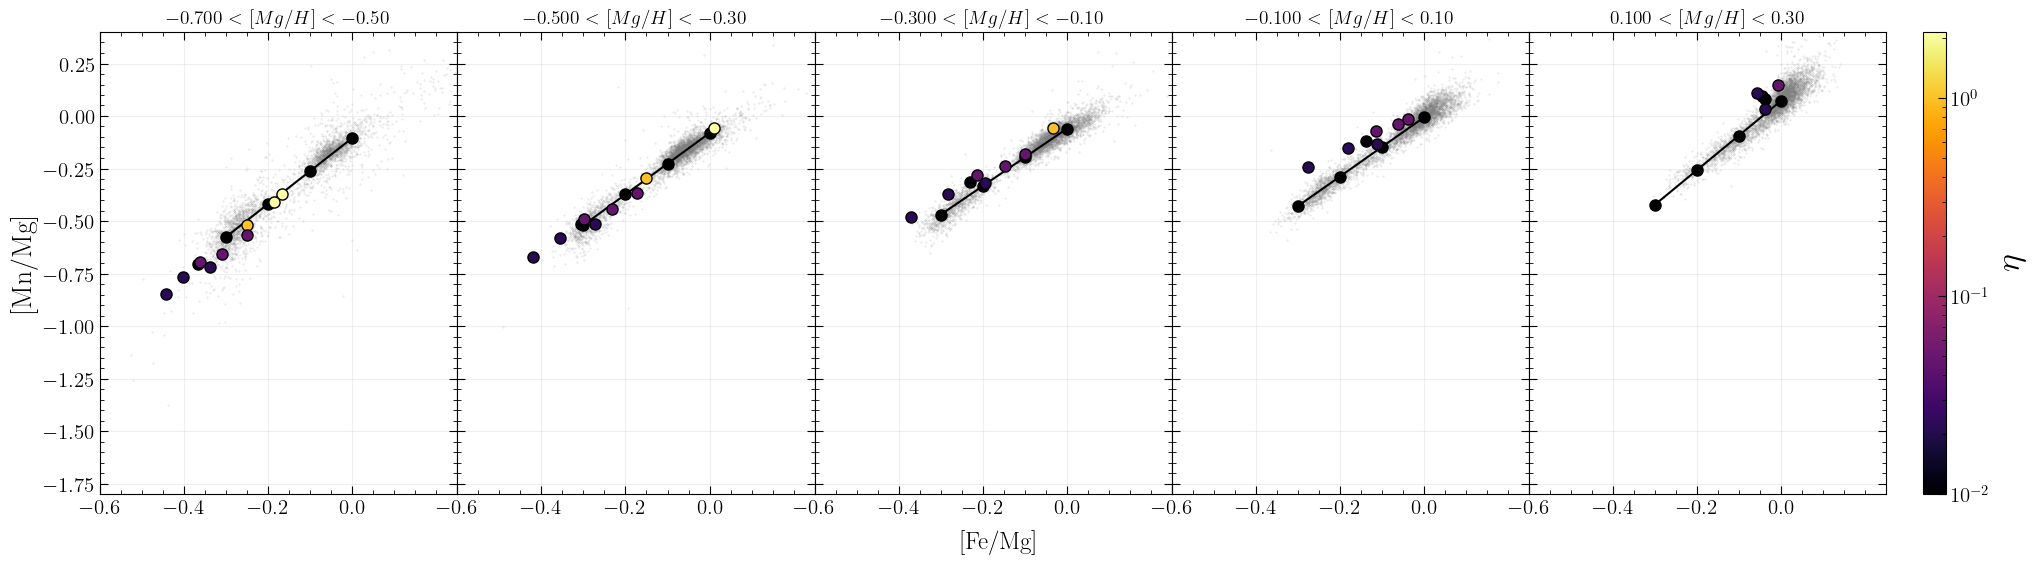

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6

# --- Extract eta values for the colormap ---
etas = [gal.eta_arr[0] for gal in gals_list]
norm = mcolors.LogNorm(vmin=min(etas), vmax=max(etas))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_mg = gal.Mn_Mg[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color based on eta
            current_color = cmap(norm(eta))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_mg, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.8, 0.40) # Adjusted ylim for Mn/Mg

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\eta$', fontsize=25)

plt.show()

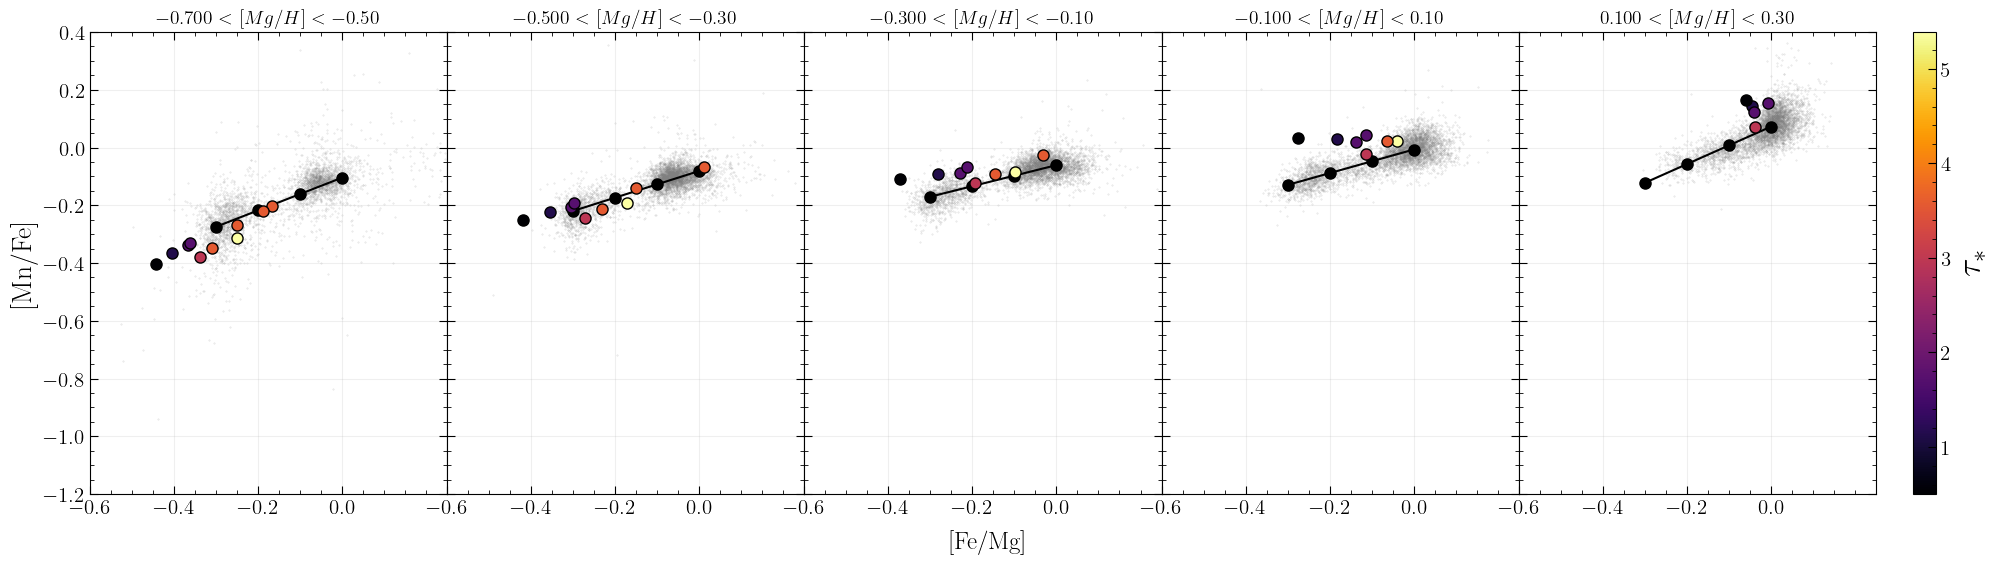

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list
# --- Extract tau* values for the colormap ---
tau_stars = [gal.tau_star_arr[0] for gal in gals_list]
norm = mcolors.Normalize(vmin=min(tau_stars), vmax=max(tau_stars))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(taustar))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\tau_*$', fontsize=25)

plt.show()

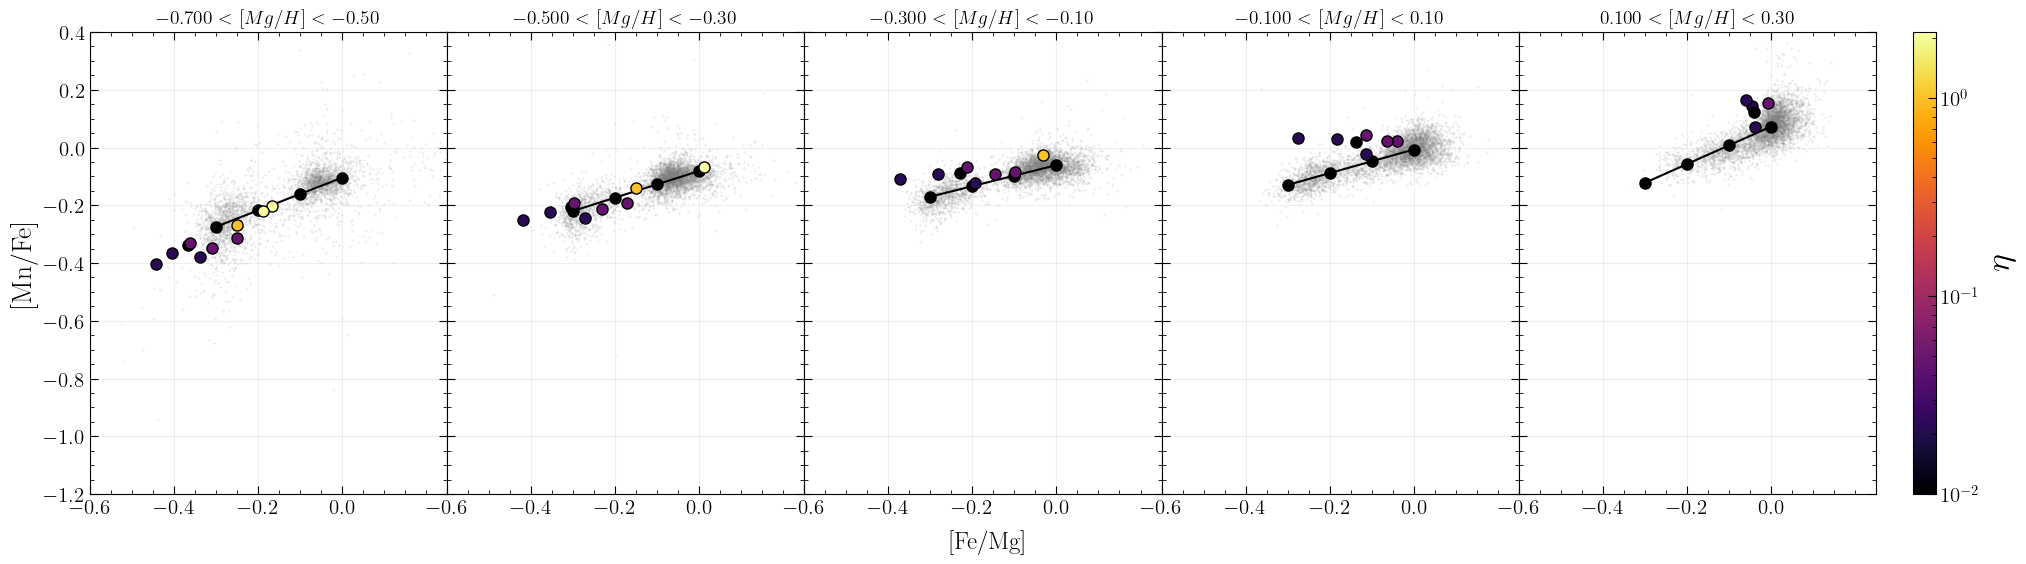

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

# --- Extract eta values for the colormap ---
etas = [gal.eta_arr[0] for gal in gals_list]
norm = mcolors.LogNorm(vmin=min(etas), vmax=max(etas))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(eta))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\eta$', fontsize=25)

plt.show()

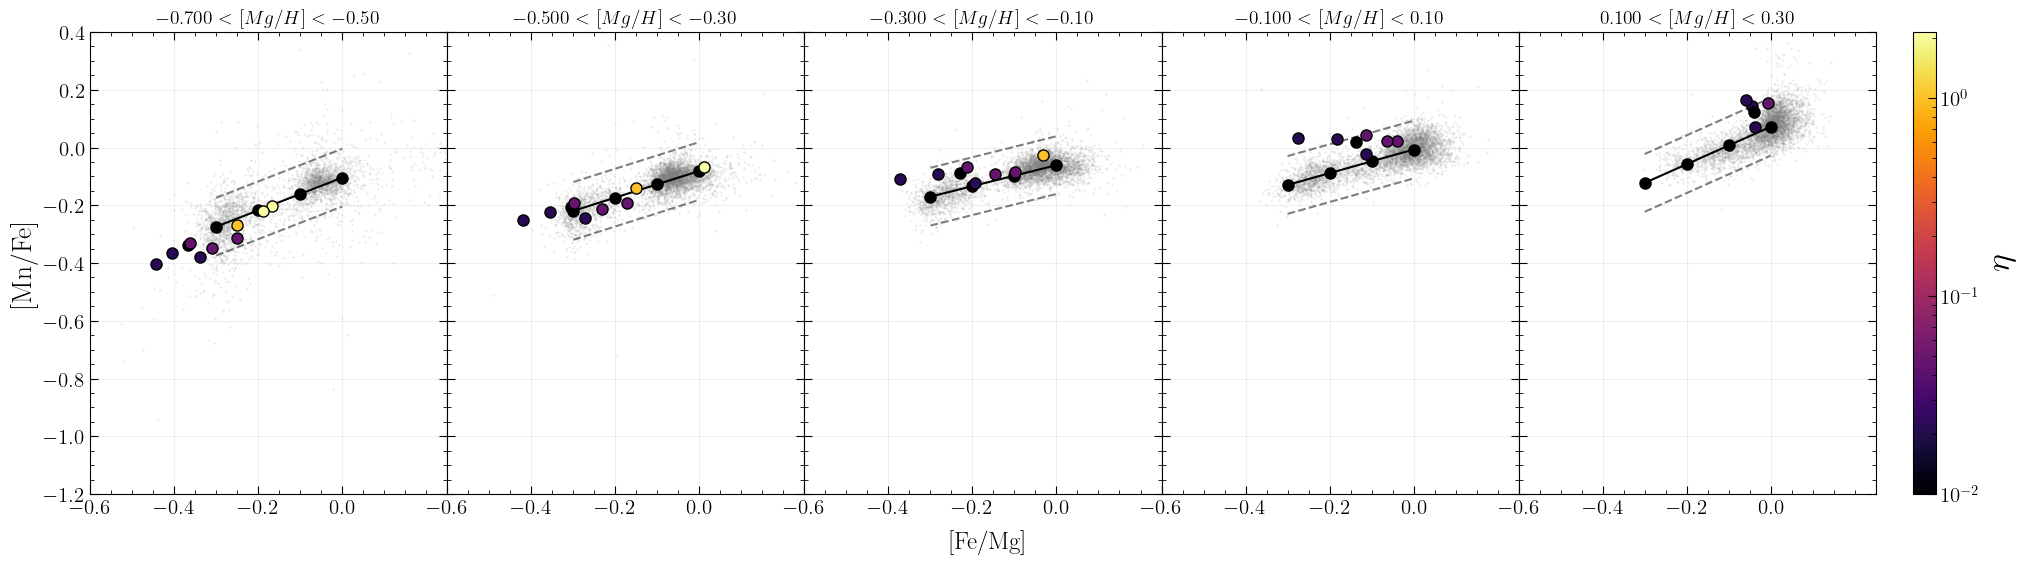

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

# --- Extract eta values for the colormap ---
etas = [gal.eta_arr[0] for gal in gals_list]
norm = mcolors.LogNorm(vmin=min(etas), vmax=max(etas))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # --- NEW: Plot parallel lines +/- 0.1 dex ---
    ax.plot(fe_mg_bin_centers, y_centers + 0.1, '--', color='black', alpha=0.5, zorder=9)
    ax.plot(fe_mg_bin_centers, y_centers - 0.1, '--', color='black', alpha=0.5, zorder=9)

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(eta))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\eta$', fontsize=25)

plt.show()

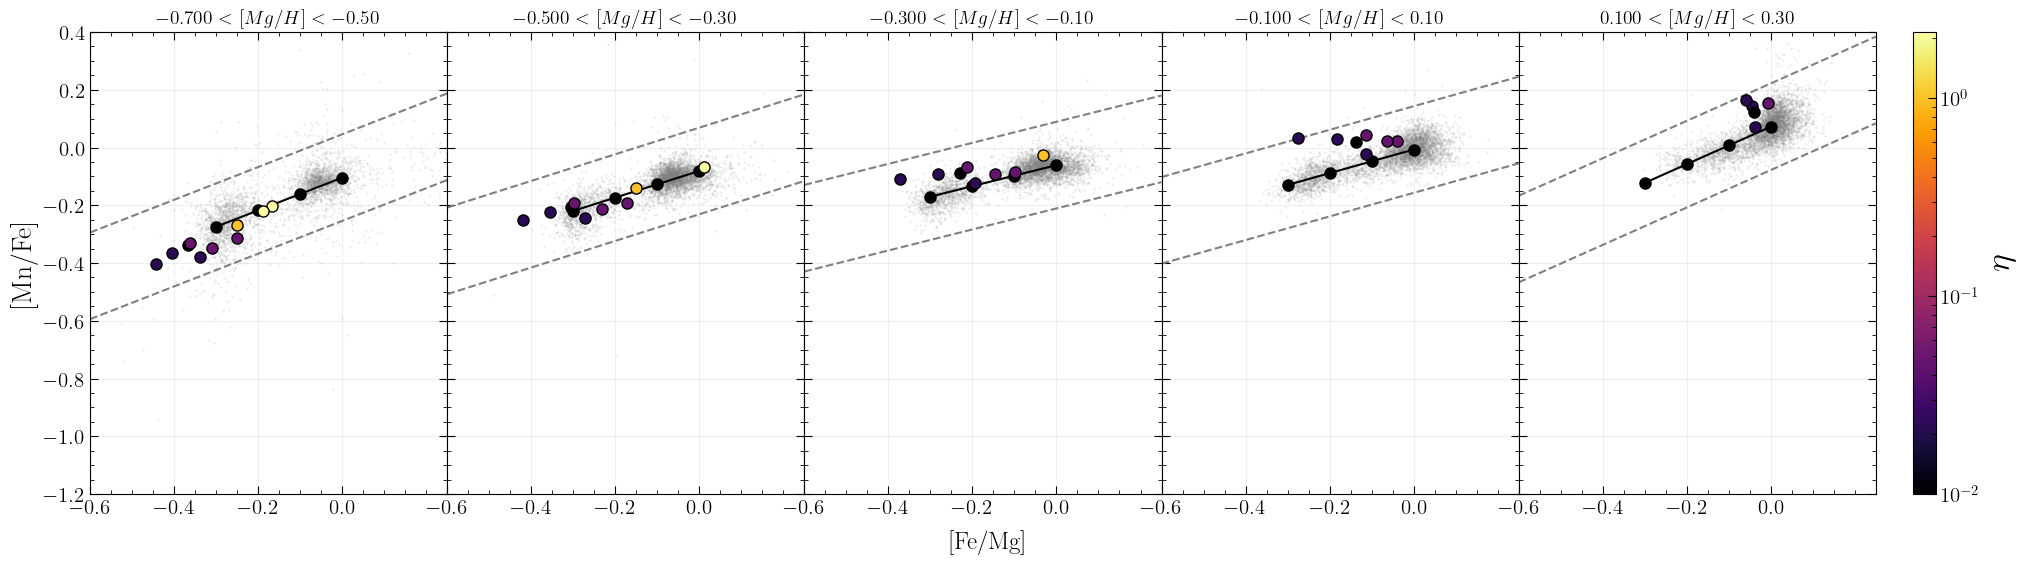

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

# --- Extract eta values for the colormap ---
etas = [gal.eta_arr[0] for gal in gals_list]
norm = mcolors.LogNorm(vmin=min(etas), vmax=max(etas))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    y_lower = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] - 0.15
    y_upper = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # --- NEW: Plot parallel lines +/- 0.1 dex ---
    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color = 'gray', linestyle = '--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color = 'gray', linestyle = '--')

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(eta))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\eta$', fontsize=25)

plt.show()

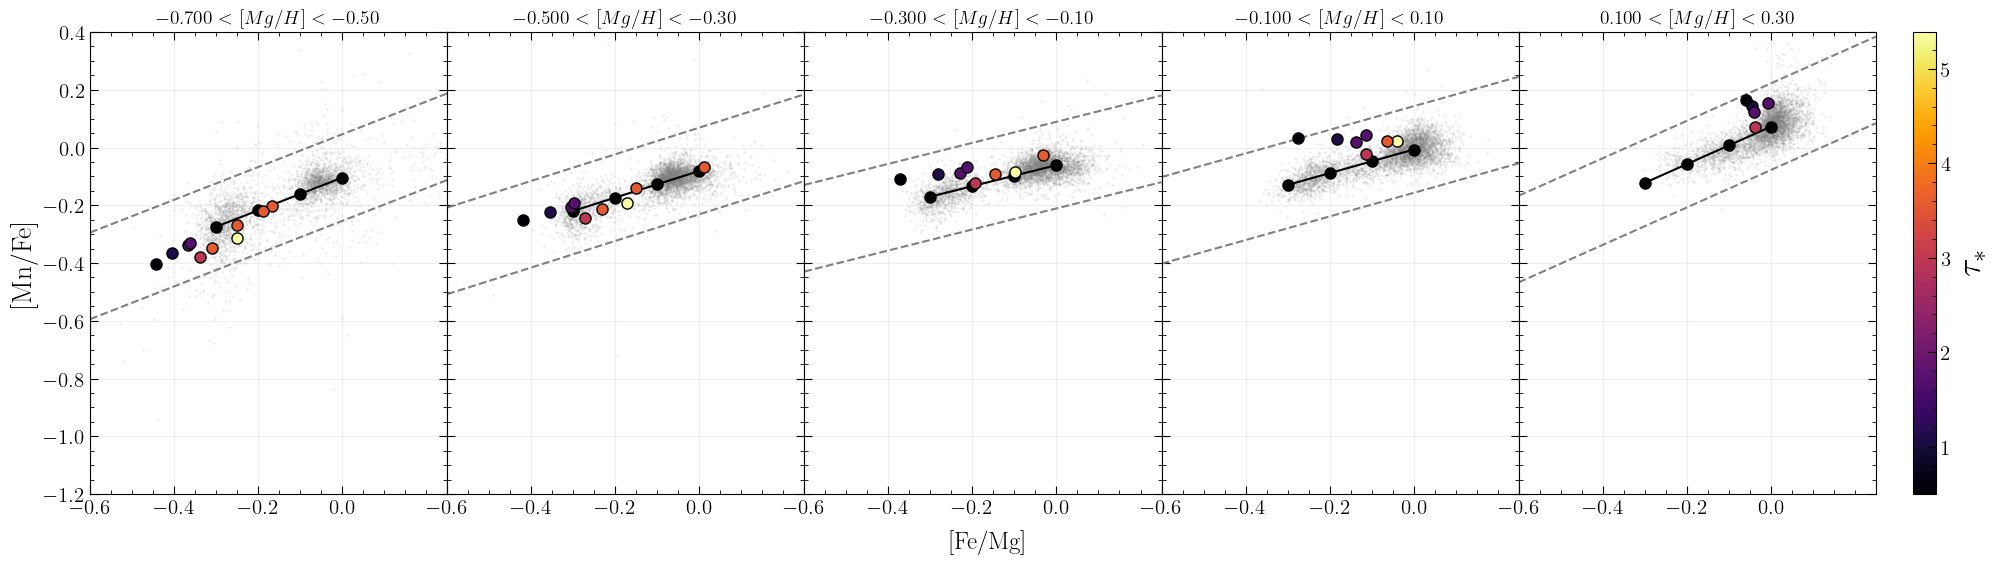

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list
# --- Extract tau* values for the colormap ---
tau_stars = [gal.tau_star_arr[0] for gal in gals_list]
norm = mcolors.Normalize(vmin=min(tau_stars), vmax=max(tau_stars))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    y_lower = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] - 0.15
    y_upper = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # --- NEW: Plot parallel lines +/- 0.1 dex ---
    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color = 'gray', linestyle = '--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color = 'gray', linestyle = '--')


    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(taustar))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\tau_*$', fontsize=25)

plt.show()

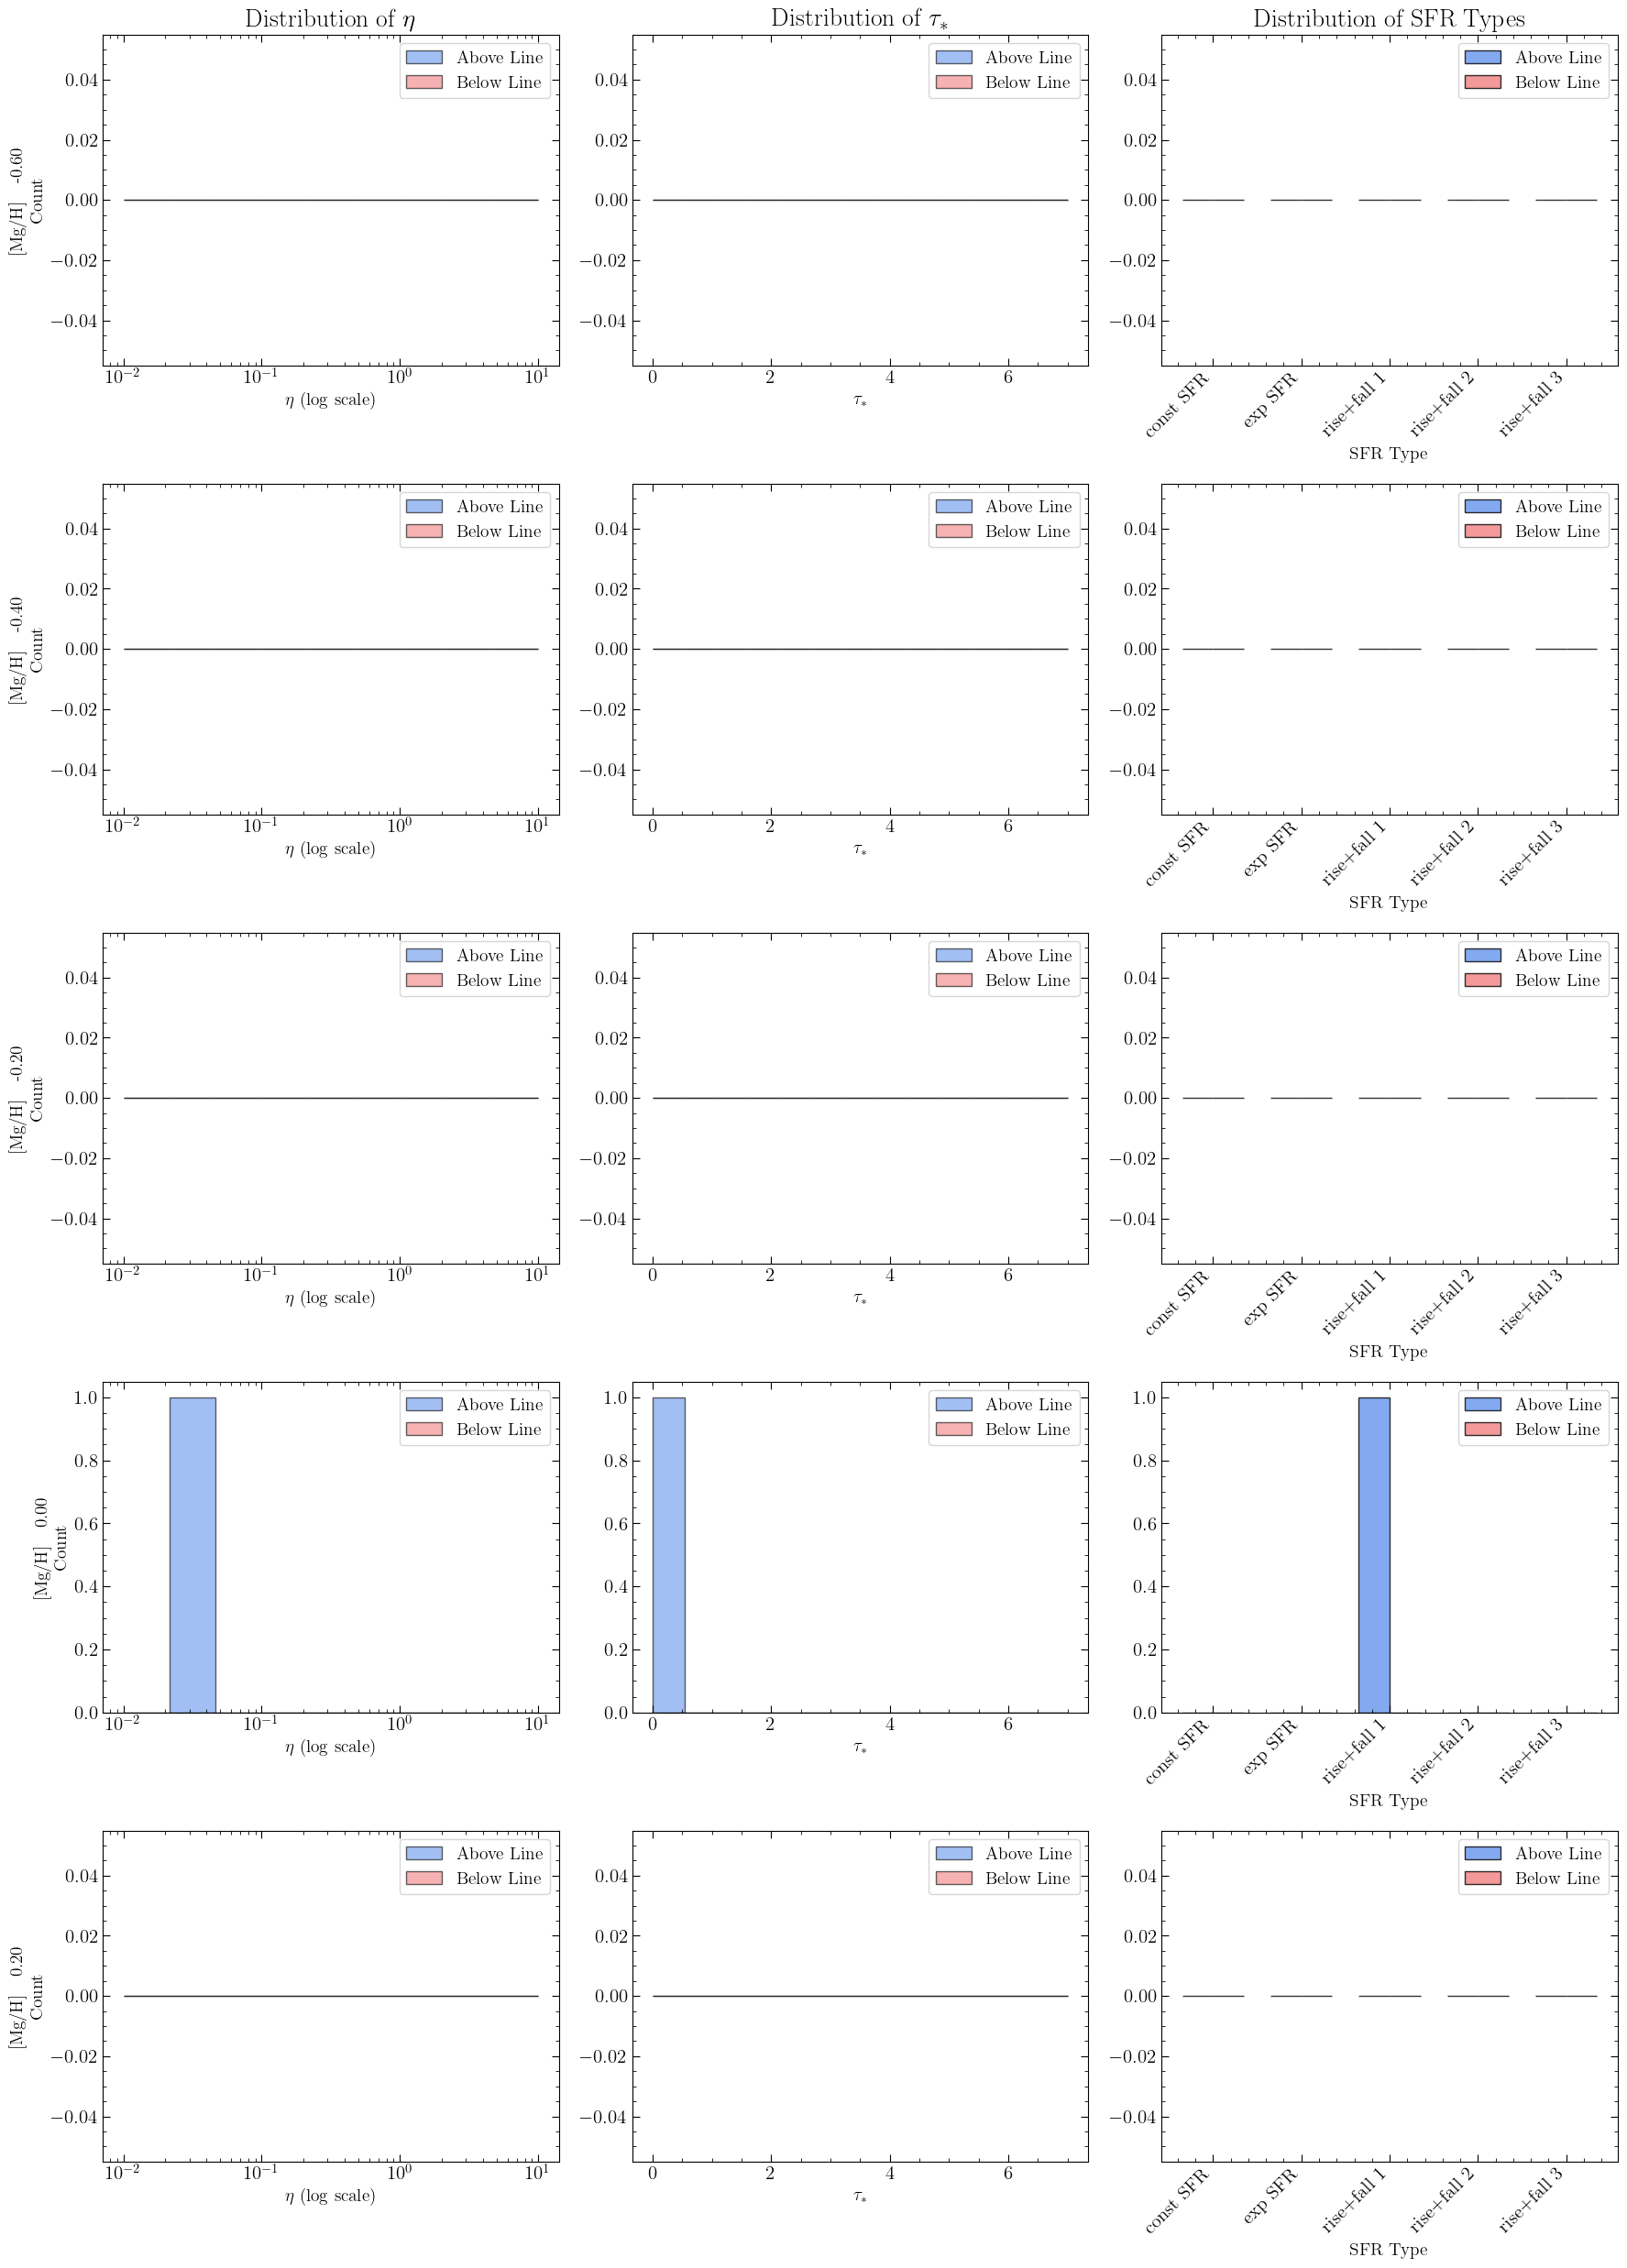

In [39]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

n_bins = len(mg_h_big_bin_centers)
# Create a grid with n_bins rows and 3 columns
fig, axes = plt.subplots(n_bins, 3, figsize=(18, 5 * n_bins), squeeze=False)

bins_eta = np.logspace(-2, 1, 10)
bins_taustar = np.linspace(0, 7, 14) 
sfr_categories = ["const SFR", "exp SFR", "rise+fall  1", "rise+fall  2", "rise+fall  3"]
x = np.arange(len(sfr_categories))
width = 0.35

for i in range(n_bins):
    # 1. Initialize lists for THIS specific bin
    above_eta, above_tau, above_sfr = [], [], []
    below_eta, below_tau, below_sfr = [], [], []
    
    idxs = gals_endpoints[i]
    slope = slopes_mn_fe[i]
    intercept = intercepts_mn_fe[i]
    bin_center = mg_h_big_bin_centers[i]
    
    # 2. Collect data for this bin
    for gal, idx in zip(random_gals_list, idxs):
        if idx != -1:
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            sfr = gal.m_g_array
            
            # Determine SFR label
            if np.array_equal(sfr, m_g_array_const): sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp): sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1): sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2): sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3): sfr_label = "rise+fall  3"
            else: sfr_label = "unknown SFR"
            
            y_line = slope * fe_mg + intercept
            y_line_upper = y_line + 0.15
            y_line_lower = y_line - 0.15
            
            if mn_fe > y_line_upper:
                above_eta.append(eta)
                above_tau.append(taustar)
                above_sfr.append(sfr_label)
            elif mn_fe < y_line_lower:
                below_eta.append(eta)
                below_tau.append(taustar)
                below_sfr.append(sfr_label)

    # 3. Plot ETA
    axes[i, 0].hist(above_eta, bins=bins_eta, alpha=0.6, label='Above Line', color='cornflowerblue', edgecolor='black')
    axes[i, 0].hist(below_eta, bins=bins_eta, alpha=0.6, label='Below Line', color='lightcoral', edgecolor='black')
    axes[i, 0].set_xscale('log')
    axes[i, 0].set_xlabel(r'$\eta$ (log scale)', fontsize=14)
    # Add bin label to the y-axis of the first column
    axes[i, 0].set_ylabel(f'[Mg/H] ~ {bin_center:.2f}\nCount', fontsize=14, fontweight='bold')
    axes[i, 0].legend()
    if i == 0: axes[i, 0].set_title(r'Distribution of $\eta$')

    # 4. Plot TAU_STAR
    axes[i, 1].hist(above_tau, bins=bins_taustar, alpha=0.6, label='Above Line', color='cornflowerblue', edgecolor='black')
    axes[i, 1].hist(below_tau, bins=bins_taustar, alpha=0.6, label='Below Line', color='lightcoral', edgecolor='black')
    axes[i, 1].set_xlabel(r'$\tau_*$', fontsize=14)
    axes[i, 1].legend()
    if i == 0: axes[i, 1].set_title(r'Distribution of $\tau_*$')

    # 5. Plot SFR
    above_counts = [Counter(above_sfr).get(cat, 0) for cat in sfr_categories]
    below_counts = [Counter(below_sfr).get(cat, 0) for cat in sfr_categories]

    axes[i, 2].bar(x - width/2, above_counts, width, label='Above Line', color='cornflowerblue', edgecolor='black', alpha=0.8)
    axes[i, 2].bar(x + width/2, below_counts, width, label='Below Line', color='lightcoral', edgecolor='black', alpha=0.8)
    axes[i, 2].set_xticks(x)
    axes[i, 2].set_xticklabels(sfr_categories, rotation=45, ha='right')
    axes[i, 2].set_xlabel('SFR Type', fontsize=14)
    axes[i, 2].legend()
    if i == 0: axes[i, 2].set_title('Distribution of SFR Types')

plt.tight_layout()
plt.show()

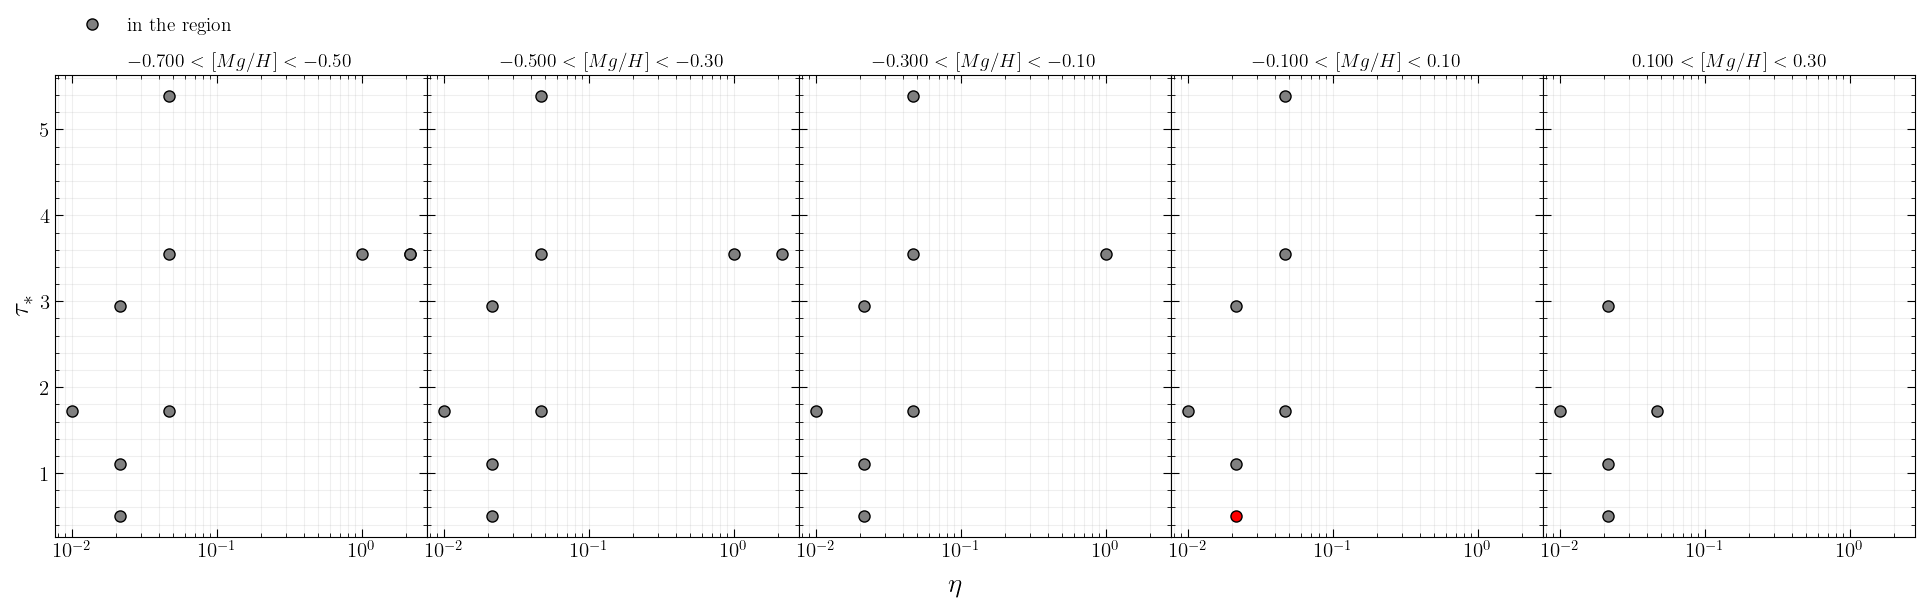

In [40]:
# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Determine color based on original y_upper and y_lower thresholds
            y_upper_val = slopes_mn_fe[i] * fe_mg + intercepts_mn_fe[i] + 0.15
            y_lower_val = slopes_mn_fe[i] * fe_mg + intercepts_mn_fe[i] - 0.15
            
            if mn_fe > y_upper_val:
                current_color = 'red'
                label = 'sig above line'
            elif mn_fe < y_lower_val:
                current_color = 'blue'
                label = 'sig below line'
            else:
                current_color = 'gray' # Default for points within the bounds
                label = 'in the region'
            
            # Removed the sfr_label block since it wasn't being used in the label string

            ax.plot(eta, taustar, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label=label)

    if i == 0:
        ax.set_ylabel(r'$\tau_*$', fontsize=20)
        
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        
        # Pins the 'lower left' of the legend box to the coordinate (0.0, 1.05)
        # ncol=3 spreads the legend items horizontally
        ax.legend(
            by_label.values(), by_label.keys(), 
            loc='lower left', 
            bbox_to_anchor=(0.0, 1.05),
            ncol=3,
            frameon=False 
        )
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    
    # Set x-axis to log scale
    ax.set_xscale('log')
    ax.grid(True, alpha=0.2, which='both') 

fig.supxlabel(r'$\eta$', fontsize=20)
fig.subplots_adjust(wspace=0)

plt.show()